# Exercise 4 — Model Training
**Task:** SemEval 2022 Task 4 Subtask 1 — Binary PCL Detection

Structured in three sections:
1. **Setup** — imports, paths, shared utilities.
2. **Baseline** — RoBERTa-base (1 epoch, 1:2 downsampling). Saved to `Models/BaselineModel/`.
3. **BestModel** — 4 × RoBERTa-base with weight + seed diversity. Trained on train set only. Saved to `Models/BestModel/`.

**Scope of this notebook:** Training and dev-set evaluation only.
- `dev.txt` and `test.txt` are not written here.
- All evaluation, predictions, and output files are produced in `Exercise_5.ipynb`.

**Approach — weight diversity ensemble:**
```
(seed=42,  pos_weight=3.0)  conservative — high precision
(seed=59,  pos_weight=5.0)
(seed=123, pos_weight=7.0)
(seed=456, pos_weight=9.5)  aggressive — matches dataset imbalance ratio
```

**Key design decisions:**
- `lr=2e-5` — standard RoBERTa-base fine-tuning rate, lower rates suitable for larger models are too conservative here.
- `num_epochs=5` with `load_best_model_at_end=True` — trains for exactly 5 epochs, then restores the checkpoint with the highest dev F1 rather than the last epoch.
- `DataCollatorWithPadding` — pads each batch to its longest sequence rather than a fixed max length, reducing wasted compute on the ~72% of samples under 64 tokens.
- `max_length=256` — covers >99.9% of samples without truncation (confirmed in Exercise 2 EDA).
- Text normalisation covers HTML entities, URLs, emails and @handles.

**Saved model structure:**
```
Models/
├── BaselineModel/      ← save_pretrained format
└── BestModel/
    ├── threshold.json  ← best threshold from dev sweep (used in Ex. 5)
    ├── seed42_w3.0/
    ├── seed59_w5.0/
    ├── seed123_w7.0/
    └── seed456_w9.5/
```

---
## 0. Setup

In [1]:
import os

# ── Mount Google Drive if running in Colab ────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')

DATA_DIR       = 'data'
PCL_TSV_PATH   = os.path.join(DATA_DIR, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_DIR, 'train_semeval_parids-labels.csv')
DEV_IDS_PATH   = os.path.join(DATA_DIR, 'dev_semeval_parids-labels.csv')

for p in [PCL_TSV_PATH, TRAIN_IDS_PATH, DEV_IDS_PATH]:
    print(f"  [{'OK' if os.path.exists(p) else 'MISSING'}]  {p}")

  [OK]  data/dontpatronizeme_pcl.tsv
  [OK]  data/train_semeval_parids-labels.csv
  [OK]  data/dev_semeval_parids-labels.csv


In [2]:
import re, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    DataCollatorWithPadding, TrainerCallback
)
from torch.utils.data import Dataset

warnings.filterwarnings('ignore')

cuda_available = torch.cuda.is_available()
mps_available  = torch.backends.mps.is_available()

if cuda_available:
    DEVICE = torch.device('cuda')
elif mps_available:
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device : {DEVICE}')
if cuda_available:   print(f'GPU    : {torch.cuda.get_device_name(0)}')
elif mps_available:  print('Backend: Apple MPS')
else:                print('Backend: CPU only')

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB


### Shared Utilities

**`compute_metrics`:** Returns positive-class F1 after every epoch. Used as `metric_for_best_model` so the Trainer saves the epoch with best PCL F1, not lowest loss — critical on a 9.5:1 imbalanced dataset.

**`DataCollatorWithPadding`:** Pads each batch dynamically to the length of its longest sequence rather than a fixed `max_length`. Short sequences waste no compute, and the model sees more natural length variation during training.

**`train_and_save`:** Checks for a saved model at `save_dir` first. If found, skips training entirely. Otherwise trains and saves with `save_pretrained`.

In [3]:
# ─── Shared Utilities ────────────────────────────────────────────────────────

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if cuda_available: torch.cuda.manual_seed_all(seed)


class PCLDataset(Dataset):
    """
    Labelled dataset — training, evaluation, and inference.
    Tokenizes without padding so DataCollatorWithPadding can pad per-batch dynamically.
    """
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts, truncation=True, max_length=max_length,
            padding=False, return_tensors=None
        )
        self.labels = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def compute_metrics(eval_pred):
    """Positive-class F1 after each epoch — used for checkpoint selection."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'f1_pcl': f1_score(labels, preds, pos_label=1, average='binary', zero_division=0)}


class WeightedTrainer(Trainer):
    """Cross-entropy with class weights. Weights moved to device at runtime."""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.cpu()
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss    = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))(logits, labels)
        return (loss, outputs) if return_outputs else loss


def train_model(model_name, seed, train_df, dev_df, class_weights,
                num_epochs=5, lr=2e-5, warmup_ratio=0.1, max_length=256, batch_size=16):
    """Fine-tune and return (model, tokenizer, dev_probs). No test data touched."""
    set_seed(seed)
    print(f"\n{'='*60}")
    print(f"Training : {model_name}")
    print(f"Seed     : {seed}  |  Weights: [{class_weights[0]:.2f}, {class_weights[1]:.2f}]  |  Device: {DEVICE}")
    print('='*60)

    tokenizer     = AutoTokenizer.from_pretrained(model_name)
    model         = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    collator      = DataCollatorWithPadding(tokenizer=tokenizer)

    train_dataset = PCLDataset(train_df['text'].tolist(), train_df['label'].tolist(), tokenizer, max_length)
    dev_dataset   = PCLDataset(dev_df['text'].tolist(),   dev_df['label'].tolist(),   tokenizer, max_length)

    args = TrainingArguments(
        output_dir                  = f'./checkpoints/{model_name.replace("/","_")}_seed{seed}',
        num_train_epochs            = num_epochs,
        per_device_train_batch_size = batch_size,
        per_device_eval_batch_size  = batch_size,
        learning_rate               = lr,
        warmup_ratio                = warmup_ratio,
        weight_decay                = 0.01,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1_pcl',
        greater_is_better           = True,
        fp16                        = False,
        bf16                        = cuda_available,
        seed                        = seed,
        report_to                   = 'none',
        logging_steps               = 50,
        save_total_limit            = 3,  # >=3 needed when patience=2 with load_best_model_at_end
    )
    trainer = WeightedTrainer(
        class_weights=class_weights, model=model, args=args,
        train_dataset=train_dataset, eval_dataset=dev_dataset,
        data_collator=collator, compute_metrics=compute_metrics,
        callbacks=[EpochLogger()],
    )
    trainer.train()

    dev_output = trainer.predict(dev_dataset)
    dev_probs  = torch.softmax(
        torch.tensor(dev_output.predictions, dtype=torch.float32), dim=-1
    )[:, 1].numpy()
    print(f'  Dev F1 @ 0.5 : {f1_score(dev_df["label"], (dev_probs >= 0.5).astype(int), zero_division=0):.4f}')
    return trainer.model, tokenizer, dev_probs


def train_and_save(model_name, seed, pos_weight, save_dir, train_df, dev_df,
                   num_epochs=5, lr=2e-5, warmup_ratio=0.1, max_length=256, batch_size=16):
    """Train + save, or load from disk if already saved. Returns dev_probs."""
    class_weights = torch.tensor([1.0, pos_weight], dtype=torch.float)

    if os.path.exists(os.path.join(save_dir, 'config.json')):
        print(f"\n[LOAD] {save_dir} — skipping training.")
        tokenizer   = AutoTokenizer.from_pretrained(save_dir)
        model       = AutoModelForSequenceClassification.from_pretrained(save_dir).to(DEVICE)
        model.eval()
        collator    = DataCollatorWithPadding(tokenizer=tokenizer)
        dev_dataset = PCLDataset(dev_df['text'].tolist(), dev_df['label'].tolist(), tokenizer, max_length)
        dev_output  = Trainer(
            model=model,
            args=TrainingArguments(output_dir='./tmp_eval', report_to='none'),
            data_collator=collator,
        ).predict(dev_dataset)
        dev_probs = torch.softmax(
            torch.tensor(dev_output.predictions, dtype=torch.float32), dim=-1
        )[:, 1].numpy()
        print(f'  Dev F1 @ 0.5 : {f1_score(dev_df["label"], (dev_probs >= 0.5).astype(int), zero_division=0):.4f}')
        del model
        if cuda_available: torch.cuda.empty_cache()
        return dev_probs

    model, tokenizer, dev_probs = train_model(
        model_name, seed, train_df, dev_df, class_weights,
        num_epochs, lr, warmup_ratio, max_length, batch_size,
    )
    os.makedirs(save_dir, exist_ok=True)
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f'  Saved to {save_dir}')
    del model
    if cuda_available: torch.cuda.empty_cache()
    return dev_probs



class EpochLogger(TrainerCallback):
    """Prints eval F1 to stdout each epoch so Colab captures it in cell output."""
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            ep   = metrics.get('epoch', state.epoch)
            f1   = metrics.get('eval_f1_pcl', float('nan'))
            loss = metrics.get('eval_loss', float('nan'))
            print(f"  Epoch {ep:.0f} | eval_loss={loss:.4f} | eval_f1_pcl={f1:.4f}")


print('Utilities ready.')

Utilities ready.


---
## 1. Data Loading

Train and dev splits only. The test set is not loaded in this notebook.

In [4]:
data = pd.read_csv(
    PCL_TSV_PATH, sep='\t', skiprows=4, header=None,
    names=['par_id', 'art_id', 'keyword', 'country', 'text', 'orig_label'],
    quoting=3, dtype={'par_id': str}
)
data = data.dropna(subset=['text', 'orig_label']).reset_index(drop=True)
data['label'] = (data['orig_label'].astype(int) >= 2).astype(int)

print(f"Full dataset : {len(data):,} rows")
print(f"PCL (1)      : {data.label.sum():,}")
print(f"Non-PCL (0)  : {(data.label == 0).sum():,}")
print(f"Imbalance    : {(data.label == 0).sum() / data.label.sum():.1f}:1")

Full dataset : 10,468 rows
PCL (1)      : 993
Non-PCL (0)  : 9,475
Imbalance    : 9.5:1


In [5]:
trids = pd.read_csv(TRAIN_IDS_PATH, usecols=['par_id'], dtype={'par_id': str})
deids = pd.read_csv(DEV_IDS_PATH,   usecols=['par_id'], dtype={'par_id': str})

def build_split(par_id_df, full_df):
    return par_id_df.merge(
        full_df[['par_id', 'text', 'label']], on='par_id', how='inner'
    ).reset_index(drop=True)

trdf = build_split(trids, data)
dedf = build_split(deids, data)

print(f"Train : {len(trdf):,} rows | PCL: {trdf.label.sum():,}  ({trdf.label.mean():.3f})")
print(f"Dev   : {len(dedf):,} rows | PCL: {dedf.label.sum():,}  ({dedf.label.mean():.3f})")

Train : 8,375 rows | PCL: 794  (0.095)
Dev   : 2,093 rows | PCL: 199  (0.095)


---
## 2. Baseline — RoBERTa-base

Official shared-task reconstruction: 1 epoch, 1:2 downsampling, threshold fixed at 0.5.
Saved to `Models/BaselineModel/`. Re-running loads from disk.

In [6]:
pcldf = trdf[trdf.label == 1]
npos  = len(pcldf)
baseline_train_df = pd.concat([
    pcldf,
    trdf[trdf.label == 0].iloc[:npos * 2]
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Baseline training set : {len(baseline_train_df):,} rows")
print(f"  PCL     : {baseline_train_df.label.sum():,}")
print(f"  Non-PCL : {(baseline_train_df.label == 0).sum():,}")

Baseline training set : 2,382 rows
  PCL     : 794
  Non-PCL : 1,588


In [7]:
BASELINE_DIR = './Models/BaselineModel'

if os.path.exists(os.path.join(BASELINE_DIR, 'config.json')):
    print(f'Saved baseline found — loading from {BASELINE_DIR}.')
    baseline_tokenizer = AutoTokenizer.from_pretrained(BASELINE_DIR)
    baseline_model     = AutoModelForSequenceClassification.from_pretrained(BASELINE_DIR).to(DEVICE)
    baseline_model.eval()
else:
    print('No saved baseline — training from scratch.')
    set_seed(42)
    baseline_tokenizer = AutoTokenizer.from_pretrained('roberta-base')
    baseline_model     = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
    Trainer(
        model         = baseline_model,
        args          = TrainingArguments(
            output_dir='./checkpoints/roberta_baseline', num_train_epochs=1,
            per_device_train_batch_size=16, per_device_eval_batch_size=16,
            learning_rate=2e-5, warmup_ratio=0.1, eval_strategy='epoch',
            save_strategy='no', fp16=cuda_available, bf16=False,
            seed=42, report_to='none', logging_steps=50,
        ),
        train_dataset = PCLDataset(baseline_train_df['text'].tolist(), baseline_train_df['label'].tolist(), baseline_tokenizer),
        eval_dataset  = PCLDataset(dedf['text'].tolist(), dedf['label'].tolist(), baseline_tokenizer),
        data_collator = DataCollatorWithPadding(tokenizer=baseline_tokenizer),
    ).train()
    os.makedirs(BASELINE_DIR, exist_ok=True)
    baseline_model.save_pretrained(BASELINE_DIR)
    baseline_tokenizer.save_pretrained(BASELINE_DIR)
    print(f'Baseline saved to {BASELINE_DIR}')


No saved baseline — training from scratch.


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,0.468705,0.288865


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Baseline saved to ./Models/BaselineModel


In [8]:
# ── Dev report ────────────────────────────────────────────────────────────────
baseline_output = Trainer(
    model=baseline_model,
    args=TrainingArguments(output_dir='./tmp_eval', report_to='none'),
    data_collator=DataCollatorWithPadding(tokenizer=baseline_tokenizer),
).predict(PCLDataset(dedf['text'].tolist(), dedf['label'].tolist(), baseline_tokenizer))

baseline_probs = torch.softmax(torch.tensor(baseline_output.predictions, dtype=torch.float32), dim=-1)[:, 1].numpy()
baseline_preds = (baseline_probs >= 0.5).astype(int)
baseline_f1    = f1_score(dedf['label'], baseline_preds, pos_label=1, average='binary')

print(f"\n{'='*50}")
print(f"Baseline Dev F1 (PCL) : {baseline_f1:.4f}")
print(f"Official target       : 0.4800")
print('='*50)
print(classification_report(dedf['label'], baseline_preds, target_names=['Non-PCL', 'PCL']))

del baseline_model
if cuda_available: torch.cuda.empty_cache()


Baseline Dev F1 (PCL) : 0.4908
Official target       : 0.4800
              precision    recall  f1-score   support

     Non-PCL       0.97      0.87      0.91      1894
         PCL       0.37      0.74      0.49       199

    accuracy                           0.85      2093
   macro avg       0.67      0.80      0.70      2093
weighted avg       0.91      0.85      0.87      2093



---
## 3. BestModel — 4 × RoBERTa-base Ensemble

| Model | Seed | pos_weight | Behaviour |
|-------|------|------------|-----------|
| 0 | 42  | 3.0 | Conservative — high precision, lower recall |
| 1 | 59  | 5.0 | Balanced-conservative |
| 2 | 123 | 7.0 | Balanced-aggressive |
| 3 | 456 | 9.5 | Aggressive — matches dataset imbalance ratio |

Trained on the **train set only**. Dev set used for per-epoch F1 evaluation and best-checkpoint selection — never in the training data. Test set not touched.

Models saved to `Models/BestModel/`. Re-running loads from disk.

### 3.1 Pre-processing

In [9]:
_URL_RE    = re.compile(r'https?://\S+|www\.\S+')
_EMAIL_RE  = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')
_HANDLE_RE = re.compile(r'@\w+')
_WS_RE     = re.compile(r'\s+')

HTML_ENTITIES = {
    '&amp;': '&',  '&lt;': '<',   '&gt;': '>',
    '&quot;': '"', '&apos;': "'", '&#39;': "'",
    '&nbsp;': ' ', '&ldquo;': '"', '&rdquo;': '"',
    '&lsquo;': "'", '&rsquo;': "'",
}

def preprocess(text: str) -> str:
    """
    Normalise text for tokenisation.
    1. HTML entity decoding  — removes encoding artefacts from web-scraped news text.
    2. URL replacement       — URLs carry no semantic signal; replaced with token 'url'.
    3. Email replacement     — same rationale; replaced with token 'email'.
    4. Handle replacement    — @mentions replaced with token 'user'.
    5. Whitespace collapse   — removes duplicate spaces left by replacements.
    """
    if not isinstance(text, str):
        return ''
    # HTML entities
    for ent, char in HTML_ENTITIES.items():
        text = text.replace(ent, char)
    text = re.sub(r'&#\d+;', ' ', text)
    # URLs, emails, handles
    text = _URL_RE.sub(' url ', text)
    text = _EMAIL_RE.sub(' email ', text)
    text = _HANDLE_RE.sub(' user ', text)
    # Whitespace
    return _WS_RE.sub(' ', text).strip()

trdf = trdf.copy(); trdf['text'] = trdf['text'].apply(preprocess)
dedf = dedf.copy(); dedf['text'] = dedf['text'].apply(preprocess)

print('Pre-processing applied to train and dev sets.')
print('  Steps: HTML entity decoding → URL/email/handle replacement → whitespace collapse')
print(f'  Train examples: {len(trdf):,}  |  Dev examples: {len(dedf):,}')

Pre-processing applied to train and dev sets.
  Steps: HTML entity decoding → URL/email/handle replacement → whitespace collapse
  Train examples: 8,375  |  Dev examples: 2,093


### 3.2 Training

4 × RoBERTa-base, each with a different seed and positive-class weight. `train_and_save` skips training and loads from disk if the model folder already exists.

**Hyperparameter choices:**
- `lr=2e-5` — standard RoBERTa-base fine-tuning rate. Lower rates appropriate for larger models are too conservative for the base variant.
- `num_epochs=5` — all models train for exactly 5 epochs. `load_best_model_at_end=True` restores the checkpoint with the highest dev F1 at the end of training, so the saved weights are not necessarily from the final epoch.
- `warmup_ratio=0.1` — linear warmup over the first 10% of training steps, appropriate for lr=2e-5.
- `batch_size=16`, `max_length=256`, `fp16=True` on CUDA.

In [10]:
ROBERTA_MODEL = 'roberta-base'
BESTMODEL_DIR = './Models/BestModel'

ENSEMBLE_CONFIGS = [
    (42,  3.0, 'seed42_w3.0'),
    (59,  5.0, 'seed59_w5.0'),
    (123, 7.0, 'seed123_w7.0'),
    (456, 9.5, 'seed456_w9.5'),
]

all_dev_probs = []

for seed, pos_weight, folder in ENSEMBLE_CONFIGS:
    dev_p = train_and_save(
        model_name=ROBERTA_MODEL, seed=seed, pos_weight=pos_weight,
        save_dir=os.path.join(BESTMODEL_DIR, folder),
        train_df=trdf, dev_df=dedf,
        num_epochs=5, lr=2e-5, warmup_ratio=0.1, max_length=256, batch_size=16,
    )
    all_dev_probs.append(dev_p)

print(f'\nTraining complete. {len(all_dev_probs)} models saved to {BESTMODEL_DIR}/')


Training : roberta-base
Seed     : 42  |  Weights: [1.00, 3.00]  |  Device: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1 Pcl
1,0.384840,0.297781,0.493671
2,0.348995,0.227503,0.512987
3,0.303023,0.308110,0.561224
4,0.040248,0.421362,0.593750
5,0.103994,0.433742,0.607527


  Epoch 1 | eval_loss=0.2978 | eval_f1_pcl=0.4937


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

  Dev F1 @ 0.5 : 0.5909


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved to ./Models/BestModel/seed456_w9.5

Training complete. 4 models saved to ./Models/BestModel/


### 3.3 Ensemble — Probability Averaging

Average the softmax P(PCL) from all 4 models. Because each model was trained with a different weight and seed, their errors are partially uncorrelated — averaging reduces variance and consistently outperforms any single model.

In [11]:
ensemble_dev = np.mean(np.stack(all_dev_probs, axis=0), axis=0)

print(f"Ensemble from {len(all_dev_probs)} models.")
print(f"Dev prob — min: {ensemble_dev.min():.3f}  max: {ensemble_dev.max():.3f}  mean: {ensemble_dev.mean():.3f}")

Ensemble from 4 models.
Dev prob — min: 0.000  max: 0.999  mean: 0.088


### 3.4 Threshold Tuning on Dev Set

The default 0.5 threshold is calibrated for balanced classes. With class-weighted loss and weight diversity across models, the optimal decision boundary shifts. All thresholds are swept on the dev set and the one that maximises positive-class F1 is picked.

The best threshold is saved to `Models/BestModel/threshold.json` for use in Exercise 5.

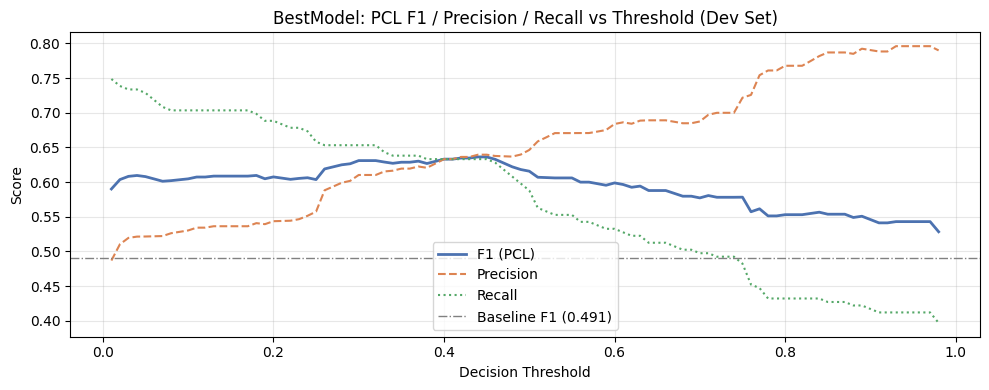

Best threshold : 0.44  |  F1=0.6364  P=0.6396  R=0.6332

Top 5 thresholds:
 threshold       f1  precision   recall
      0.44 0.636364   0.639594 0.633166
      0.45 0.636364   0.639594 0.633166
      0.42 0.634761   0.636364 0.633166
      0.43 0.634761   0.636364 0.633166
      0.40 0.633166   0.633166 0.633166

Threshold saved to ./Models/BestModel/threshold.json


In [12]:
dev_labels = dedf['label'].values
thresholds = np.arange(0.01, 0.99, 0.01)

results = [{
    'threshold': round(t, 2),
    'f1':        f1_score(dev_labels, (ensemble_dev >= t).astype(int), zero_division=0),
    'precision': precision_score(dev_labels, (ensemble_dev >= t).astype(int), zero_division=0),
    'recall':    recall_score(dev_labels, (ensemble_dev >= t).astype(int), zero_division=0),
} for t in thresholds]
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results_df['threshold'], results_df['f1'],        label='F1 (PCL)',  lw=2,   color='#4C72B0')
ax.plot(results_df['threshold'], results_df['precision'], label='Precision', lw=1.5, linestyle='--', color='#DD8452')
ax.plot(results_df['threshold'], results_df['recall'],    label='Recall',    lw=1.5, linestyle=':',  color='#55A868')
ax.axhline(baseline_f1, linestyle='-.', color='grey', lw=1, label=f'Baseline F1 ({baseline_f1:.3f})')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('BestModel: PCL F1 / Precision / Recall vs Threshold (Dev Set)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_row       = results_df.loc[results_df['f1'].idxmax()]
BEST_THRESHOLD = best_row['threshold']
print(f"Best threshold : {BEST_THRESHOLD:.2f}  |  F1={best_row['f1']:.4f}  P={best_row['precision']:.4f}  R={best_row['recall']:.4f}")
print(f"\nTop 5 thresholds:")
print(results_df.nlargest(5, 'f1').to_string(index=False))

os.makedirs(BESTMODEL_DIR, exist_ok=True)
with open(os.path.join(BESTMODEL_DIR, 'threshold.json'), 'w') as f:
    json.dump({'best_threshold': float(BEST_THRESHOLD)}, f, indent=2)
print(f"\nThreshold saved to {BESTMODEL_DIR}/threshold.json")

### 3.5 Per-Model F1 Comparison

Comparing each model individually against the ensemble shows how much the averaging helps, and confirms that weight diversity produces genuinely different operating points.

In [13]:
print(f"Per-model dev F1 @ threshold=0.5 and @ best threshold ({BEST_THRESHOLD:.2f}):\n")

for (seed, pos_weight, folder), probs in zip(ENSEMBLE_CONFIGS, all_dev_probs):
    f1_05 = f1_score(dev_labels, (probs >= 0.5).astype(int),            zero_division=0)
    f1_bt = f1_score(dev_labels, (probs >= BEST_THRESHOLD).astype(int), zero_division=0)
    p_bt  = precision_score(dev_labels, (probs >= BEST_THRESHOLD).astype(int), zero_division=0)
    r_bt  = recall_score(dev_labels,    (probs >= BEST_THRESHOLD).astype(int), zero_division=0)
    print(f"  seed={seed:<4} w={pos_weight:<4}  F1@0.5={f1_05:.4f}  F1@{BEST_THRESHOLD:.2f}={f1_bt:.4f}  P={p_bt:.4f}  R={r_bt:.4f}")

ensemble_f1 = f1_score(dev_labels, (ensemble_dev >= BEST_THRESHOLD).astype(int), zero_division=0)
print(f"  {'Ensemble':<22}                  F1@{BEST_THRESHOLD:.2f}={ensemble_f1:.4f}")
print(f"\n{'─'*55}")
print(f"  Baseline RoBERTa-base     F1 = {baseline_f1:.4f}")
print(f"  BestModel RoBERTa-base ensemble      F1 = {ensemble_f1:.4f}")
print(f"  Improvement                +{ensemble_f1 - baseline_f1:.4f}")

Per-model dev F1 @ threshold=0.5 and @ best threshold (0.44):

  seed=42   w=3.0   F1@0.5=0.6075  F1@0.44=0.6059  P=0.6494  R=0.5678
  seed=59   w=5.0   F1@0.5=0.6228  F1@0.44=0.6212  P=0.6244  R=0.6181
  seed=123  w=7.0   F1@0.5=0.5856  F1@0.44=0.5856  P=0.5784  R=0.5930
  seed=456  w=9.5   F1@0.5=0.5909  F1@0.44=0.5915  P=0.6731  R=0.5276
  Ensemble                                F1@0.44=0.6364

───────────────────────────────────────────────────────
  Baseline RoBERTa-base     F1 = 0.4908
  BestModel RoBERTa-base ensemble      F1 = 0.6364
  Improvement                +0.1455


### 3.6 Classification Report — Dev Set

In [14]:
ensemble_preds = (ensemble_dev >= BEST_THRESHOLD).astype(int)

print(f"BestModel — Dev Set  (threshold={BEST_THRESHOLD:.2f})")
print('='*55)
print(classification_report(dev_labels, ensemble_preds, target_names=['Non-PCL', 'PCL']))

BestModel — Dev Set  (threshold=0.44)
              precision    recall  f1-score   support

     Non-PCL       0.96      0.96      0.96      1894
         PCL       0.64      0.63      0.64       199

    accuracy                           0.93      2093
   macro avg       0.80      0.80      0.80      2093
weighted avg       0.93      0.93      0.93      2093



---
## 4. Appendix - Clean up workspace

In [15]:
import shutil
from pathlib import Path

tmp_eval_path = Path("./tmp_eval")
checkpoint_path = Path("./checkpoints")

if tmp_eval_path.exists():
    shutil.rmtree(tmp_eval_path)
    print(f"Deleted: {tmp_eval_path.resolve()}")
else:
    print(f"Not found (nothing to delete): {tmp_eval_path.resolve()}")

if checkpoint_path.exists():
    shutil.rmtree(checkpoint_path)
    print(f"Deleted: {checkpoint_path.resolve()}")
else:
    print(f"Not found (nothing to delete): {checkpoint_path.resolve()}")

Deleted: /content/tmp_eval
Deleted: /content/checkpoints
